# **TMDB Top 10,000 Movies (Updated 2026)**
Nguồn dataset: https://www.kaggle.com/datasets/siddharthbhakta/tmdb-top-10000-movies-updated-2026/data

Người thực hiện: Võ Bạch Kim Thịnh

# 1. ĐỌC DỮ LIỆU & TIỀN XỬ LÝ

Trong bước này, chúng ta sẽ thực hiện các công việc nền tảng để chuẩn bị dữ liệu sạch và tối ưu cho quá trình phân tích (EDA) hoặc xây dựng mô hình tiếp theo. Các bước thực hiện bao gồm:
1. **Kết nối hệ thống:** Kết nối Google Colab với Google Drive để truy cập tập dữ liệu.
2. **Khởi tạo môi trường:** Import các thư viện phân tích dữ liệu cốt lõi (`pandas`, `numpy`, `os`).
3. **Tải dữ liệu & Khảo sát sơ bộ:** Đọc file CSV, loại bỏ các trường thừa (`Unnamed: 0`), kiểm tra cấu trúc cột, kiểu dữ liệu (`df.info()`) và phân phối thống kê (`df.describe()`).
4. **Xử lý giá trị khuyết thiếu (Missing Values):** Đưa ra phương án xử lý thích hợp cho thuộc tính văn bản (`overview`) và thuộc tính thời gian (`release_date`).
5. **Chuẩn hóa kiểu dữ liệu:** Chuyển đổi dữ liệu ngày tháng về đúng định dạng chuỗi thời gian (`datetime`).
6. **Kỹ nghệ đặc trưng (Feature Engineering):** Tạo thêm các cột dữ liệu mới giàu thông tin hơn như năm phát hành, tháng phát hành, độ dài văn bản tóm tắt và thu gọn nhóm ngôn ngữ gốc.

In [2]:
# Import thư viện pandas để thao tác cấu trúc dữ liệu DataFrame
import pandas as pd

# Import thư viện numpy để xử lý các phép toán và giá trị số/mảng
import numpy as np

# Import thư viện os để tương tác với hệ thống tệp tin
import os

# Import thư viện drive từ google.colab để cấu hình kết nối tới Google Drive
from google.colab import drive

# Tiến hành kết nối (mount) Google Drive vào môi trường Colab tại thư mục '/content/drive'
# Bạn cần nhấn vào link xác thực hoặc đồng ý cấp quyền khi dòng này chạy
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Định nghĩa đường dẫn chính xác tới file dữ liệu trên Google Drive của bạn
file_path = "/content/drive/MyDrive/Data/moviesTMBD.csv"

# Kiểm tra xem tệp tin có tồn tại tại đường dẫn đã khai báo hay không để tránh lỗi crash code
if os.path.exists(file_path):
    # Đọc dữ liệu từ file CSV vào DataFrame đặt tên là df
    df = pd.read_csv(file_path)
    print("--- TẢI DỮ LIỆU THÀNH CÔNG! ---\n")

    # Kiểm tra và loại bỏ cột 'Unnamed: 0' (cột này thường xuất hiện khi lưu file mà quên đặt index=False)
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], axis=1, inplace=True)
        print("-> Đã loại bỏ thành công cột thừa 'Unnamed: 0'.\n")

    # Hiển thị 5 dòng đầu tiên của DataFrame để quan sát trực quan cấu trúc bản ghi
    print("--- 5 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU ---")
    display(df.head(5))

    # Sử dụng df.info() để kiểm tra số lượng dòng không null và kiểu dữ liệu của từng cột
    print("\n--- THÔNG TIN TỔNG QUAN VỀ KIỂU DỮ LIỆU (df.info()) ---")
    df.info()

    # Sử dụng df.describe() để thống kê mô tả (bao gồm cả dữ liệu số và định danh với include='all')
    print("\n--- THỐNG KÊ MÔ TẢ TỔNG QUAN (df.describe()) ---")
    display(df.describe(include='all'))
else:
    print(f"LỖI: Không tìm thấy file dữ liệu tại đường dẫn: {file_path}. Vui lòng kiểm tra lại cấu trúc thư mục trên Google Drive.")

--- TẢI DỮ LIỆU THÀNH CÔNG! ---

-> Đã loại bỏ thành công cột thừa 'Unnamed: 0'.

--- 5 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU ---


,id,title,popularity,adult,original_language,overview,release_date,vote_average,vote_count
0,1007757,Swapped,327.5134,False,en,"A small woodland creature and a majestic bird,...",2026-05-01,8.987,1320
1,278,The Shawshank Redemption,65.3308,False,en,Imprisoned in the 1940s for the double murder ...,1994-09-23,8.721,30387
2,238,The Godfather,47.2346,False,en,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,8.686,22929
3,687163,Project Hail Mary,422.0199,False,en,Science teacher Ryland Grace wakes up on a spa...,2026-03-15,8.621,3950
4,240,The Godfather Part II,27.6763,False,en,In the continuing saga of the Corleone crime f...,1974-12-20,8.571,13901



--- THÔNG TIN TỔNG QUAN VỀ KIỂU DỮ LIỆU (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9980 entries, 0 to 9979
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 9980 non-null   int64  
 1   title              9980 non-null   object 
 2   popularity         9980 non-null   float64
 3   adult              9980 non-null   bool   
 4   original_language  9980 non-null   object 
 5   overview           9978 non-null   object 
 6   release_date       9978 non-null   object 
 7   vote_average       9980 non-null   float64
 8   vote_count         9980 non-null   int64  
dtypes: bool(1), float64(2), int64(2), object(4)
memory usage: 633.6+ KB

--- THỐNG KÊ MÔ TẢ TỔNG QUAN (df.describe()) ---


,id,title,popularity,adult,original_language,overview,release_date,vote_average,vote_count
count,9.980000e+03,9980,9980.000000,9980,9980,9978,9978,9980.000000,9980.000000
unique,NaN,9105,NaN,1,44,9415,6069,NaN,NaN
top,NaN,Return,NaN,False,en,All the couples are back for a wedding in Las ...,2021-02-12,NaN,NaN
freq,NaN,12,NaN,9980,7746,2,10,NaN,NaN
mean,2.322215e+05,NaN,4.690097,NaN,NaN,NaN,NaN,6.750276,2115.381263
std,3.087803e+05,NaN,11.973625,NaN,NaN,NaN,NaN,0.641034,3373.638027
min,2.000000e+00,NaN,0.008600,NaN,NaN,NaN,NaN,5.500000,300.000000
25%,1.042775e+04,NaN,1.818600,NaN,NaN,NaN,NaN,6.249750,477.000000
50%,4.333150e+04,NaN,2.768400,NaN,NaN,NaN,NaN,6.716500,871.000000
75%,4.145662e+05,NaN,4.689025,NaN,NaN,NaN,NaN,7.216000,2125.000000


### Kiểm tra và Đánh giá tình trạng dữ liệu thiếu (Missing Values)

Việc xử lý giá trị thiếu là bắt buộc trước khi phân tích sâu hơn:
- Đối với cột `overview` (Tóm tắt phim): Đây là dữ liệu dạng văn bản (Text). Việc thiếu thông tin không làm ảnh hưởng đến cấu trúc dòng, do đó chúng ta sẽ thay thế các giá trị NaN bằng một chuỗi rỗng `""`. Điều này giúp tránh lỗi lỗi định dạng khi phân tích văn bản hoặc NLP sau này.
- Đối với cột `release_date` (Ngày phát hành): Đây là biến quan trọng liên quan đến phân tích chuỗi thời gian. Nếu số lượng dòng bị thiếu ngày phát hành chiếm tỷ lệ rất nhỏ, phương án tối ưu là loại bỏ hoàn toàn các dòng này để dữ liệu phân tích theo thời gian không bị sai lệch.

In [4]:
# Kiểm tra số lượng giá trị thiếu (Null/NaN) cụ thể ở từng cột trước khi xử lý
print("Số lượng giá trị thiếu ở mỗi cột ban đầu:")
print(df.isnull().sum())

# 1. Xử lý giá trị thiếu cho cột 'overview': thay thế NaN bằng chuỗi trống ""
df['overview'] = df['overview'].fillna("")
print("\n-> Đã xử lý giá trị thiếu cho cột 'overview' bằng cách điền chuỗi rỗng.")

# 2. Xử lý giá trị thiếu cho cột 'release_date': loại bỏ các dòng bị khuyết ngày phát hành
df.dropna(subset=['release_date'], inplace=True)
print("-> Đã xóa các dòng bị khuyết thiếu dữ liệu ở cột 'release_date'.")

# 3. Chuẩn hóa định dạng cột 'release_date' sang kiểu datetime của pandas
# Tham số errors='coerce' sẽ chuyển các giá trị ngày tháng sai cú pháp hoặc không hợp lệ thành NaT (Not a Time)
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Tiếp tục loại bỏ các dòng có ngày tháng không hợp lệ (giá trị NaT vừa tạo ra nếu có)
df.dropna(subset=['release_date'], inplace=True)
print("-> Đã chuyển đổi thành công cột 'release_date' sang định dạng chuỗi thời gian datetime chuẩn.")

# Reset lại chỉ mục (index) của DataFrame sau khi xóa dòng để chỉ mục chạy liên tục từ 0
df.reset_index(drop=True, inplace=True)

Số lượng giá trị thiếu ở mỗi cột ban đầu:
id                   0
title                0
popularity           0
adult                0
original_language    0
overview             2
release_date         2
vote_average         0
vote_count           0
dtype: int64

-> Đã xử lý giá trị thiếu cho cột 'overview' bằng cách điền chuỗi rỗng.
-> Đã xóa các dòng bị khuyết thiếu dữ liệu ở cột 'release_date'.
-> Đã chuyển đổi thành công cột 'release_date' sang định dạng chuỗi thời gian datetime chuẩn.


### Kỹ nghệ đặc trưng (Feature Engineering)

Kỹ nghệ đặc trưng giúp chúng ta biến đổi và tạo ra các góc nhìn mới từ các thuộc tính cũ, tăng hiệu quả phân tích:
1. **`release_year` (Năm phát hành):** Trích xuất từ cột `release_date` giúp dễ dàng gom nhóm, vẽ biểu đồ xu hướng sản xuất phim qua các năm hoặc các thập kỷ.
2. **`release_month` (Tháng phát hành):** Trích xuất tháng phát hành để phục vụ phân tích tính mùa vụ (ví dụ: Phim bom tấn thường chọn ra rạp vào tháng mấy?).
3. **`overview_length` (Độ dài tóm tắt):** Sử dụng hàm đếm từ trong chuỗi văn bản của cột `overview` để tính độ dài, phục vụ cho việc tìm mối tương quan giữa độ dài tóm tắt với điểm số hay độ phổ biến của phim.
4. **Thu gọn biến `original_language` (Ngôn ngữ gốc):** Cột này có thể chứa hàng chục ngôn ngữ khác nhau nhưng phân phối thường rất lệch (phần lớn là tiếng Anh - 'en'). Để giảm nhiễu, chúng ta sẽ tìm ra Top 5 ngôn ngữ phổ biến nhất và giữ nguyên chúng; toàn bộ các ngôn ngữ hiếm gặp còn lại sẽ được gộp chung thành một nhóm duy nhất mang tên `'Other'`.

In [5]:
# 1. Trích xuất năm phát hành bằng thuộc tính .dt.year từ định dạng datetime
df['release_year'] = df['release_date'].dt.year

# 2. Trích xuất tháng phát hành bằng thuộc tính .dt.month từ định dạng datetime
df['release_month'] = df['release_date'].dt.month

# 3. Tạo cột 'overview_length' bằng cách tách từ qua khoảng trắng và đếm độ dài danh sách từ
# Sử dụng hàm lambda kết hợp với phương thức split() để đếm số lượng từ
df['overview_length'] = df['overview'].apply(lambda x: len(str(x).split()) if x else 0)

# 4. Xử lý tối ưu hóa cột 'original_language'
# Bước 4a: Lấy danh sách Top 5 ngôn ngữ xuất hiện nhiều nhất trong tập dữ liệu dưới dạng list
top_5_languages = df['original_language'].value_counts().nlargest(5).index.tolist()
print(f"Top 5 ngôn ngữ phổ biến nhất được giữ lại: {top_5_languages}")

# Bước 4b: Sử dụng hàm lambda để chuyển đổi các ngôn ngữ ngoài Top 5 thành 'Other'
df['original_language'] = df['original_language'].apply(lambda lang: lang if lang in top_5_languages else 'Other')

print("\n-> Hoàn thành quá trình Kỹ nghệ đặc trưng (Feature Engineering)!")

Top 5 ngôn ngữ phổ biến nhất được giữ lại: ['en', 'fr', 'it', 'ja', 'es']

-> Hoàn thành quá trình Kỹ nghệ đặc trưng (Feature Engineering)!


In [6]:
# Hiển thị lại 5 dòng đầu tiên của DataFrame sau khi đã hoàn thành toàn bộ các bước xử lý dữ liệu
print("--- 5 DÒNG ĐẦU TIÊN CỦA DATAFRAME SAU KHI TIỀN XỬ LÝ VÀ THÊM ĐẶC TRƯNG ---")
display(df.head(5))

# In ra kích thước (số dòng, số cột) hiện tại để kiểm tra sự thay đổi cấu trúc dữ liệu
print(f"\nKích thước hiện tại của tập dữ liệu: {df.shape[0]} dòng và {df.shape[1]} cột.")

# Kiểm tra lại một lần cuối xem còn cột nào chứa giá trị khuyết thiếu (Null) hay không
print("\n--- BẢNG KIỂM TRA GIÁ TRỊ NULL SAU CÙNG ---")
null_summary = df.isnull().sum()
display(null_summary)

# Đưa ra kết luận tổng kết dựa trên tổng số lượng ô null còn lại
if null_summary.sum() == 0:
    print("\n[KẾT LUẬN]: Dữ liệu đã hoàn toàn SẠCH, không còn giá trị null và sẵn sàng cho bước Phân tích khám phá (EDA) tiếp theo!")
else:
    print("\n[CẢNH BÁO]: Vẫn còn giá trị khuyết thiếu trong DataFrame, hãy kiểm tra kỹ lại các bước tiền xử lý phía trên.")

--- 5 DÒNG ĐẦU TIÊN CỦA DATAFRAME SAU KHI TIỀN XỬ LÝ VÀ THÊM ĐẶC TRƯNG ---


,id,title,popularity,adult,original_language,overview,release_date,vote_average,vote_count,release_year,release_month,overview_length
0,1007757,Swapped,327.5134,False,en,"A small woodland creature and a majestic bird,...",2026-05-01,8.987,1320,2026,5,51
1,278,The Shawshank Redemption,65.3308,False,en,Imprisoned in the 1940s for the double murder ...,1994-09-23,8.721,30387,1994,9,69
2,238,The Godfather,47.2346,False,en,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,8.686,22929,1972,3,48
3,687163,Project Hail Mary,422.0199,False,en,Science teacher Ryland Grace wakes up on a spa...,2026-03-15,8.621,3950,2026,3,65
4,240,The Godfather Part II,27.6763,False,en,In the continuing saga of the Corleone crime f...,1974-12-20,8.571,13901,1974,12,39



Kích thước hiện tại của tập dữ liệu: 9978 dòng và 12 cột.

--- BẢNG KIỂM TRA GIÁ TRỊ NULL SAU CÙNG ---


,0
id,0
title,0
popularity,0
adult,0
original_language,0
overview,0
release_date,0
vote_average,0
vote_count,0
release_year,0



[KẾT LUẬN]: Dữ liệu đã hoàn toàn SẠCH, không còn giá trị null và sẵn sàng cho bước Phân tích khám phá (EDA) tiếp theo!


# 2. TRỰC QUAN HÓA DỮ LIỆU (EXPLORATORY DATA ANALYSIS - EDA)

Mục tiêu của bước này là chuyển đổi các con số khô khan thành các thông tin trực quan trực quan trực diện nhằm:
1. **Hiểu rõ phân phối của dữ liệu:** Xác định xem các biến số có bị lệch (skewed) hay chứa nhiều dữ liệu ngoại lai (outliers) hay không.
2. **Khám phá mối quan hệ tương quan:** Tìm kiếm các mô thức (patterns) ẩn giấu giữa các yếu tố (ví dụ: Liệu phim có lượng bình chọn cao thì điểm số có cao hơn không?).
3. **Phân tích xu hướng thời gian:** Theo dõi dòng chảy phát triển của ngành điện ảnh qua các năm về cả số lượng lẫn mức độ đại chúng.

Chúng ta sẽ lần lượt triển khai **10 biểu đồ chuyên nghiệp** đan xen qua các góc nhìn phân phối, tương quan, phân loại và thời gian.

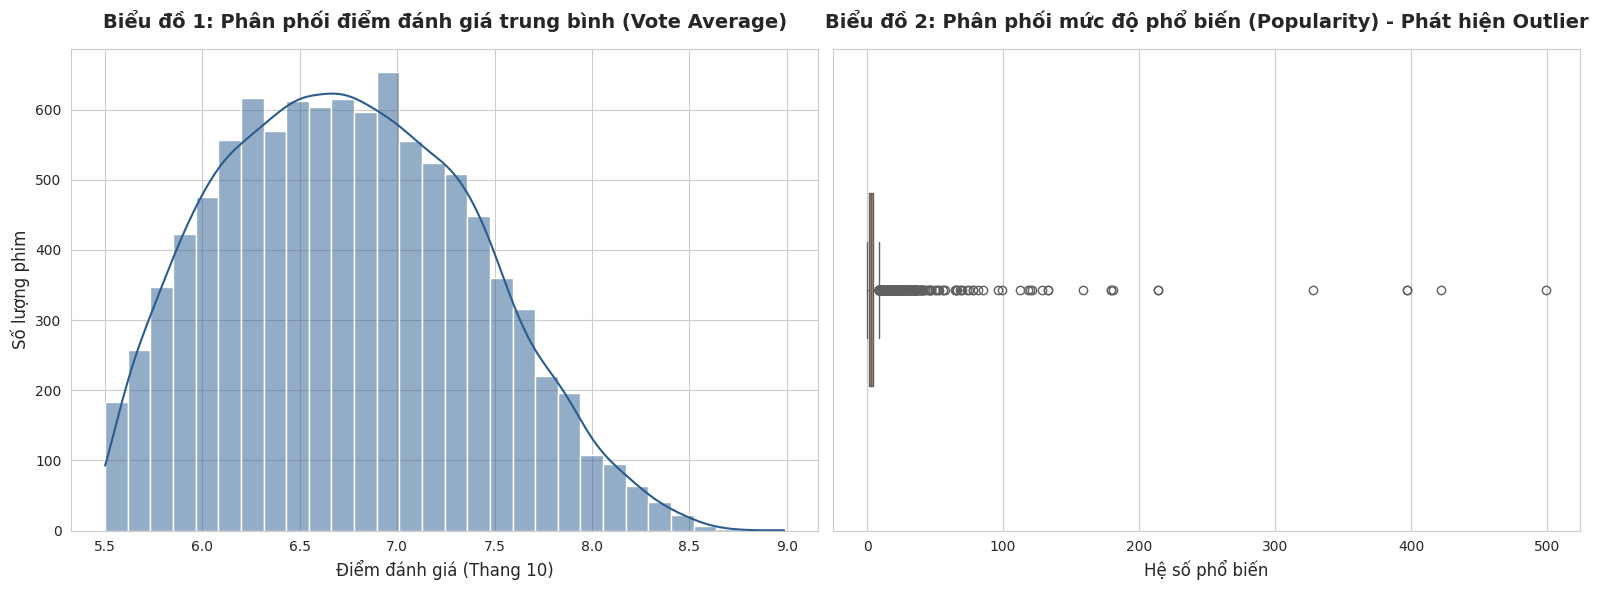

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện biểu đồ mặc định trực quan, sạch sẽ và hiện đại
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100  # Tăng độ nét cho hình ảnh hiển thị trong Colab

# Khởi tạo khung hình gồm 1 dòng và 2 cột cho Biểu đồ 1 và Biểu đồ 2
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 1: Phân phối của điểm đánh giá vote_average (Histogram + KDE) ---
sns.histplot(data=df, x='vote_average', kde=True, bins=30, ax=axes[0], color='#2b5c8f')
axes[0].set_title('Biểu đồ 1: Phân phối điểm đánh giá trung bình (Vote Average)', fontsize=14, pad=15, fontweight='bold')
axes[0].set_xlabel('Điểm đánh giá (Thang 10)', fontsize=12)
axes[0].set_ylabel('Số lượng phim', fontsize=12)

# --- BIỂU ĐỒ 2: Phân phối của độ phổ biến popularity (Boxplot) ---
sns.boxplot(data=df, x='popularity', ax=axes[1], color='#e07a5f', width=0.4)
axes[1].set_title('Biểu đồ 2: Phân phối mức độ phổ biến (Popularity) - Phát hiện Outlier', fontsize=14, pad=15, fontweight='bold')
axes[1].set_xlabel('Hệ số phổ biến', fontsize=12)

# Tối ưu khoảng cách giữa các biểu đồ con để tránh chồng lấn văn bản
plt.tight_layout()
plt.show()

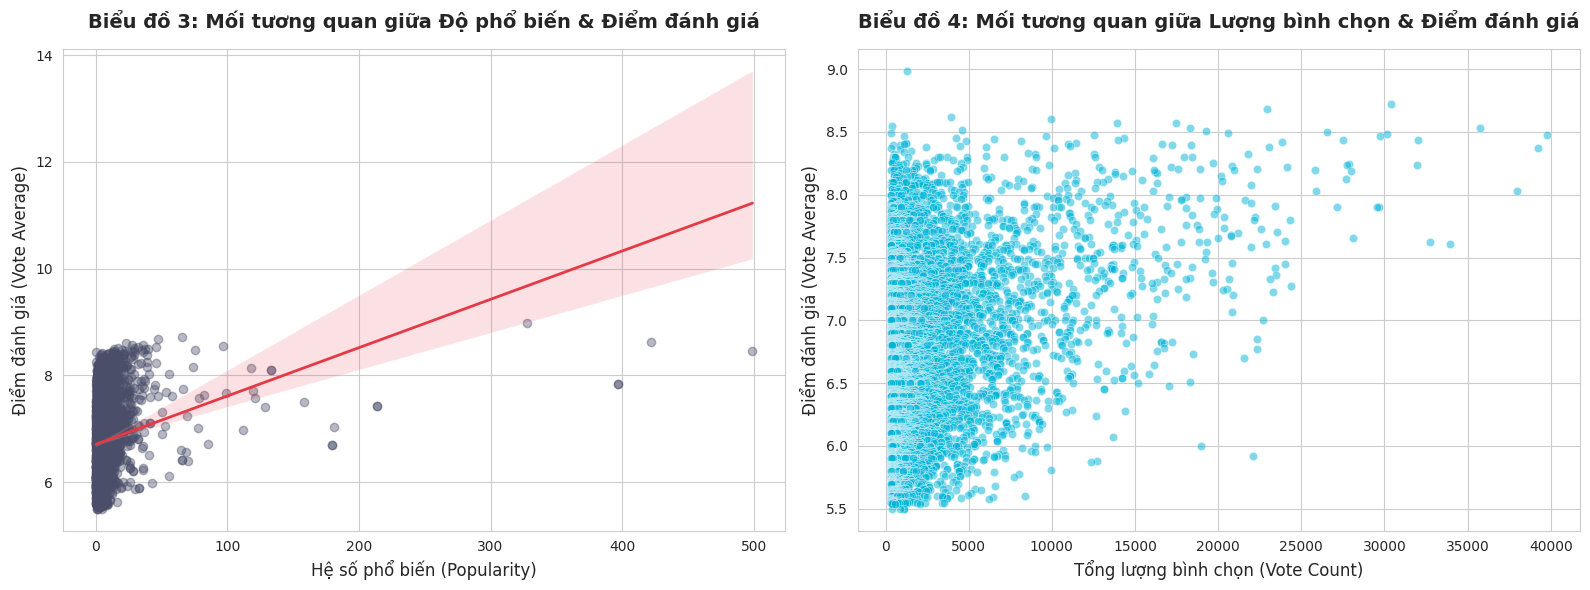

In [8]:
# Khởi tạo khung hình gồm 1 dòng và 2 cột cho Biểu đồ 3 và Biểu đồ 4
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 3: Mối quan hệ giữa Popularity và Vote Average (Scatter plot có xu hướng) ---
# Sử dụng regplot để vẽ đường xu hướng tuyến tính (trendline) màu đỏ làm nổi bật mối tương quan
sns.regplot(data=df, x='popularity', y='vote_average', ax=axes[0],
            scatter_kws={'alpha':0.4, 'color':'#4a4e69'}, line_kws={'color':'#e63946', 'linewidth':2})
axes[0].set_title('Biểu đồ 3: Mối tương quan giữa Độ phổ biến & Điểm đánh giá', fontsize=14, pad=15, fontweight='bold')
axes[0].set_xlabel('Hệ số phổ biến (Popularity)', fontsize=12)
axes[0].set_ylabel('Điểm đánh giá (Vote Average)', fontsize=12)

# --- BIỂU ĐỒ 4: Mối quan hệ giữa Vote Count và Vote Average (Scatter plot) ---
# Sử dụng thuộc tính alpha để giảm thiểu hiện tượng chồng chập dữ liệu (overplotting) do mật độ dày
sns.scatterplot(data=df, x='vote_count', y='vote_average', ax=axes[1], alpha=0.5, color='#00b4d8')
axes[1].set_title('Biểu đồ 4: Mối tương quan giữa Lượng bình chọn & Điểm đánh giá', fontsize=14, pad=15, fontweight='bold')
axes[1].set_xlabel('Tổng lượng bình chọn (Vote Count)', fontsize=12)
axes[1].set_ylabel('Điểm đánh giá (Vote Average)', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_6878/1068059131.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_counts.index, y=lang_counts.values, ax=axes[0], palette='crest')
/tmp/ipykernel_6878/1068059131.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top5_lang, x='original_language', y='vote_average', ax=axes[1],


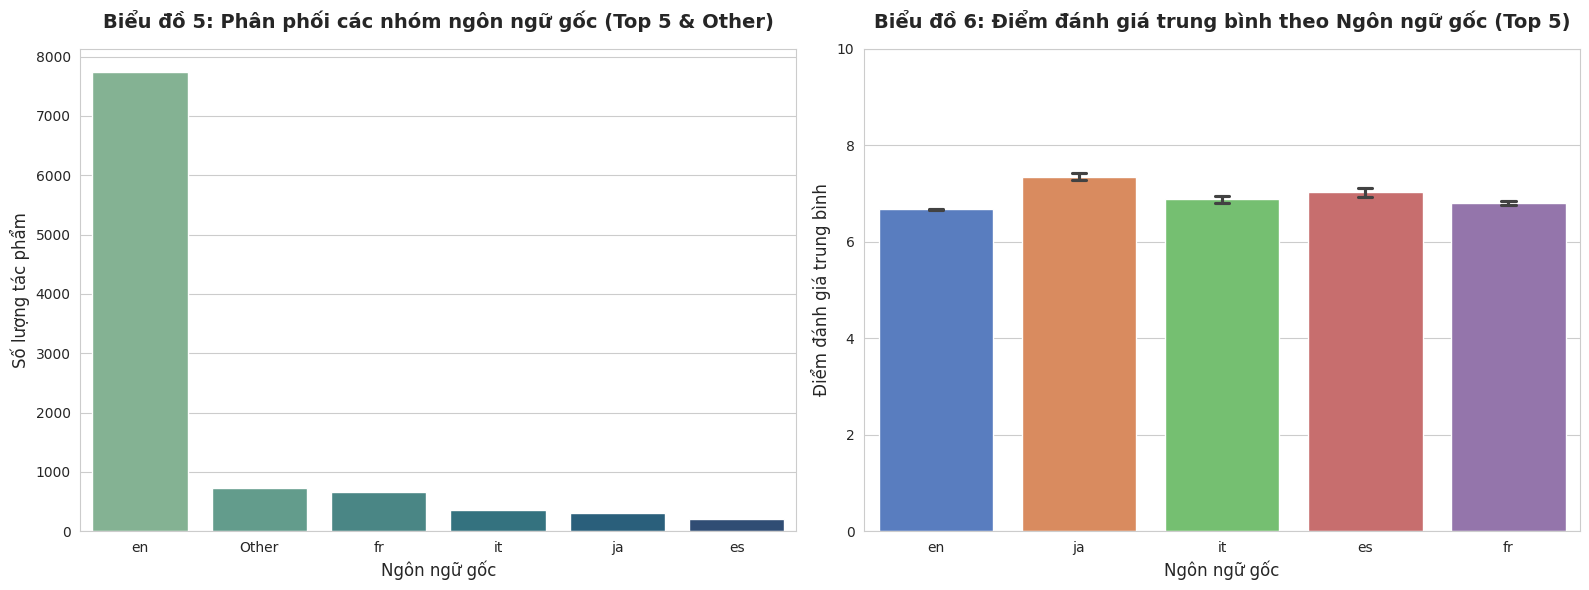

In [9]:
# Khởi tạo khung hình gồm 1 dòng và 2 cột cho Biểu đồ 5 và Biểu đồ 6
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 5: Tần suất các nhóm ngôn ngữ gốc phổ biến nhất (Bar plot) ---
# Thống kê tần suất xuất hiện của cột ngôn ngữ (sau khi đã xử lý thu gọn ở bước trước thành Top 5 + Other)
lang_counts = df['original_language'].value_counts()
sns.barplot(x=lang_counts.index, y=lang_counts.values, ax=axes[0], palette='crest')
axes[0].set_title('Biểu đồ 5: Phân phối các nhóm ngôn ngữ gốc (Top 5 & Other)', fontsize=14, pad=15, fontweight='bold')
axes[0].set_xlabel('Ngôn ngữ gốc', fontsize=12)
axes[0].set_ylabel('Số lượng tác phẩm', fontsize=12)

# --- BIỂU ĐỒ 6: Điểm vote_average trung bình theo từng ngôn ngữ trong Top 5 (Bar plot có thanh sai số) ---
# Lọc bỏ nhóm 'Other' để chỉ phân tích sâu độ lệch điểm số của riêng Top 5 ngôn ngữ chính thống
df_top5_lang = df[df['original_language'] != 'Other']
sns.barplot(data=df_top5_lang, x='original_language', y='vote_average', ax=axes[1],
            palette='muted', errorbar='ci', capsize=0.1)
axes[1].set_title('Biểu đồ 6: Điểm đánh giá trung bình theo Ngôn ngữ gốc (Top 5)', fontsize=14, pad=15, fontweight='bold')
axes[1].set_xlabel('Ngôn ngữ gốc', fontsize=12)
axes[1].set_ylabel('Điểm đánh giá trung bình', fontsize=12)
axes[1].set_ylim(0, 10) # Cố định trục Y từ 0-10 để phản ánh trực quan bản chất thang điểm

plt.tight_layout()
plt.show()

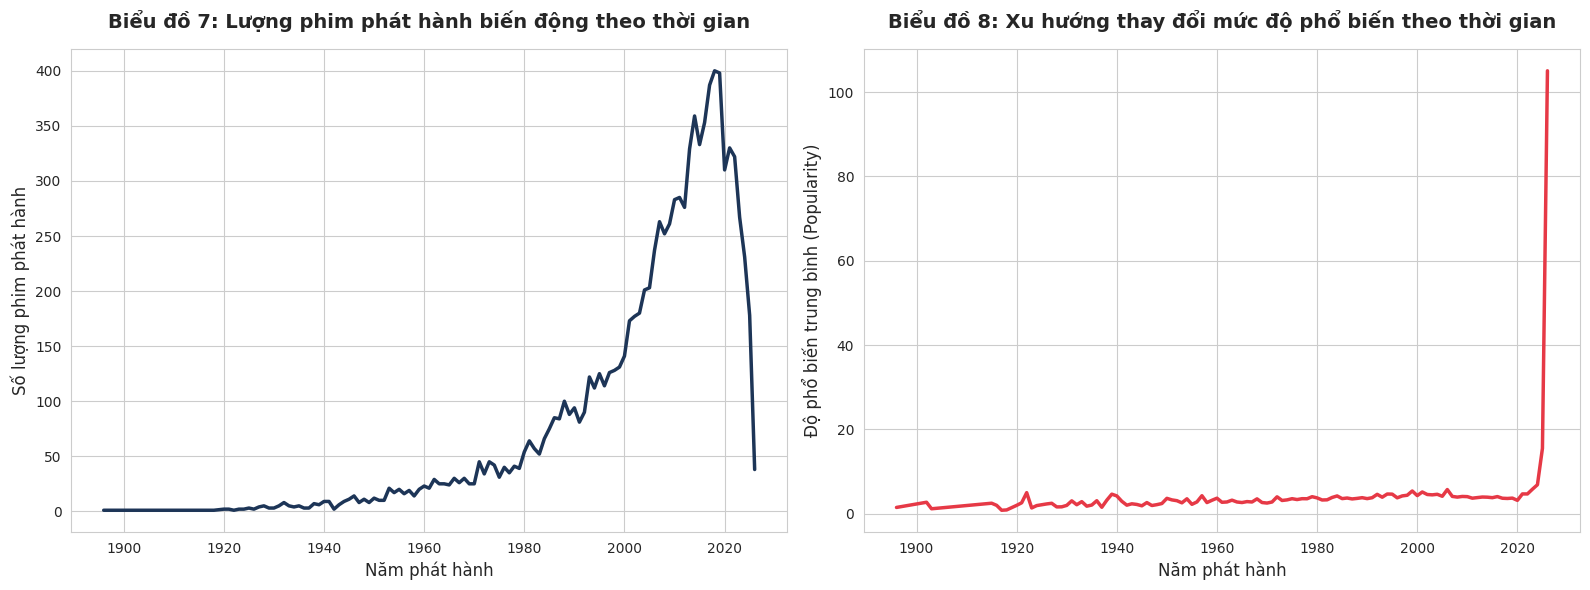

In [10]:
# Khởi tạo khung hình gồm 1 dòng và 2 cột cho Biểu đồ 7 và Biểu đồ 8
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 7: Số lượng phim được phát hành theo năm (Line plot) ---
# Gom nhóm dữ liệu theo từng năm phát hành và đếm số lượng ID phim tương ứng
movies_by_year = df.groupby('release_year')['id'].count().reset_index()
sns.lineplot(data=movies_by_year, x='release_year', y='id', ax=axes[0], color='#1d3557', linewidth=2.5)
axes[0].set_title('Biểu đồ 7: Lượng phim phát hành biến động theo thời gian', fontsize=14, pad=15, fontweight='bold')
axes[0].set_xlabel('Năm phát hành', fontsize=12)
axes[0].set_ylabel('Số lượng phim phát hành', fontsize=12)

# --- BIỂU ĐỒ 8: Xu hướng độ phổ biến trung bình thay đổi qua các năm (Line plot) ---
# Gom nhóm tính hệ số phổ biến trung bình (Mean of Popularity) qua từng năm phát hành
pop_by_year = df.groupby('release_year')['popularity'].mean().reset_index()
sns.lineplot(data=pop_by_year, x='release_year', y='popularity', ax=axes[1], color='#e63946', linewidth=2.5)
axes[1].set_title('Biểu đồ 8: Xu hướng thay đổi mức độ phổ biến theo thời gian', fontsize=14, pad=15, fontweight='bold')
axes[1].set_xlabel('Năm phát hành', fontsize=12)
axes[1].set_ylabel('Độ phổ biến trung bình (Popularity)', fontsize=12)

plt.tight_layout()
plt.show()

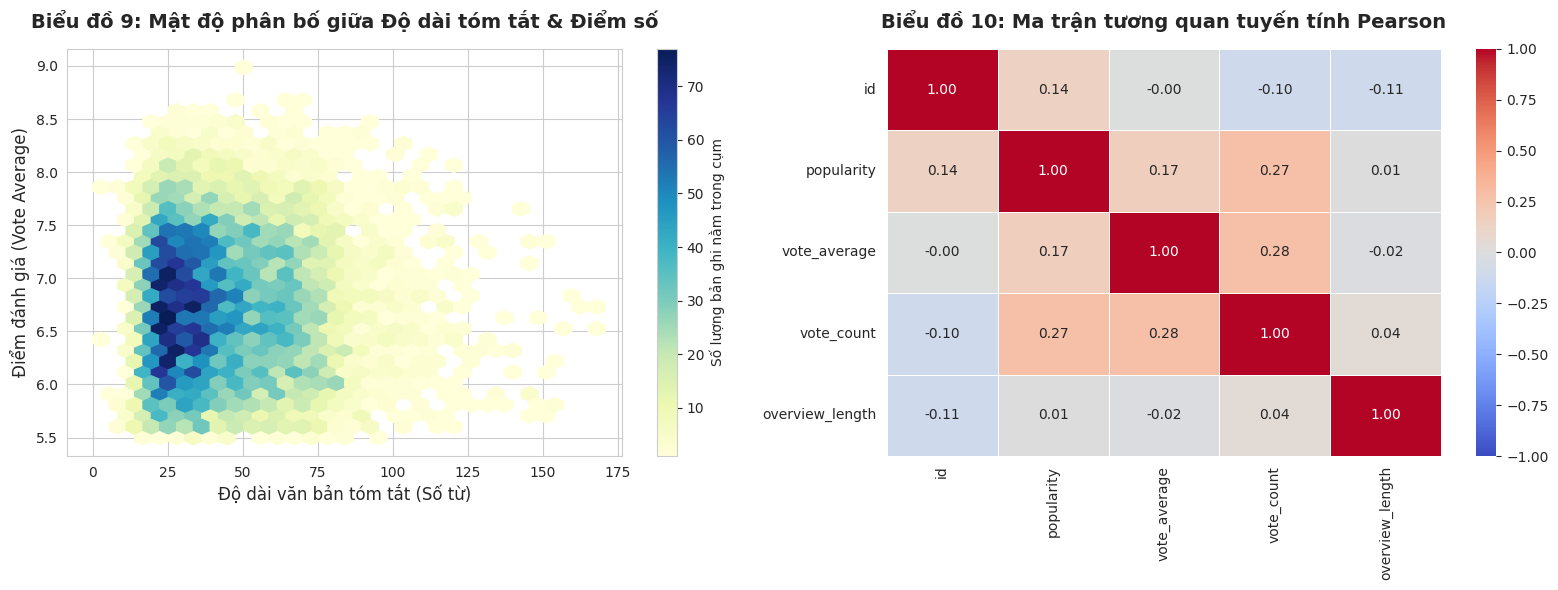

In [11]:
# Khởi tạo khung hình gồm 1 dòng và 2 cột cho Biểu đồ 9 và Biểu đồ 10
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 9: Mối quan hệ giữa độ dài phần overview_length và điểm vote_average (Hexbin plot) ---
# Sử dụng hexbin để gom cụm mật độ dữ liệu lớn, giúp nhìn rõ vùng phân bố tập trung dày nhất mà scatter thường bị mờ
hb = axes[0].hexbin(df['overview_length'], df['vote_average'], gridsize=30, cmap='YlGnBu', mincnt=1)
fig.colorbar(hb, ax=axes[0], label='Số lượng bản ghi nằm trong cụm')
axes[0].set_title('Biểu đồ 9: Mật độ phân bố giữa Độ dài tóm tắt & Điểm số', fontsize=14, pad=15, fontweight='bold')
axes[0].set_xlabel('Độ dài văn bản tóm tắt (Số từ)', fontsize=12)
axes[0].set_ylabel('Điểm đánh giá (Vote Average)', fontsize=12)

# --- BIỂU ĐỒ 10: Ma trận tương quan Heatmap giữa tất cả các biến số ---
# Lọc lấy danh sách các cột có kiểu dữ liệu là số (Numeric) để thực hiện tính toán ma trận Pearson
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# Vẽ ma trận tương quan dạng nhiệt lượng, hiển thị rõ giá trị số cụ thể làm tròn 2 chữ số thập phân
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Biểu đồ 10: Ma trận tương quan tuyến tính Pearson', fontsize=14, pad=15, fontweight='bold')

plt.tight_layout()
plt.show()

### BÁO CÁO TÓM TẮT NHẬN XÉT ĐỊNH TÍNH TỪ KẾT QUẢ ĐỒ THỊ

Dựa trên chuỗi 10 biểu đồ chuyên nghiệp đã trực quan hóa, chúng ta có thể rút ra một số nhận định sơ bộ về tập dữ liệu phim TMDB như sau:

* **Xu hướng phân phối điểm số và độ phổ biến (Biểu đồ 1 & 2):**
    * Điểm đánh giá trung bình (`vote_average`) tập trung chủ yếu quanh mức từ [ĐIỀN GIÁ TRỊ VÙNG ĐỈNH, ví dụ: 6.0 đến 7.0], có dạng hình chuông gần như phân phối chuẩn nhưng hơi lệch trái.
    * Chỉ số `popularity` có độ lệch phải rất cao với một danh sách dài các điểm ngoại lai (Outliers) phía trên. Điều này chứng tỏ phần lớn các bộ phim có mức độ đại chúng ổn định trung bình, chỉ có một lượng nhỏ tác phẩm "bom tấn" đạt mức độ phủ sóng cực kỳ vượt trội.

* **Sự tương quan giữa hiệu ứng truyền thông và chất lượng chuyên môn (Biểu đồ 3 & 4):**
    * [ĐIỀN SUY LUẬN TỪ ĐỒ THỊ 3, ví dụ: Xu hướng đường thẳng cho thấy mối tương quan đồng biến nhẹ/rõ ràng giữa độ phổ biến và điểm đánh giá...].
    * Lượng bình chọn (`vote_count`) và điểm số có hiện tượng hội tụ: Những bộ phim có lượng bình chọn cực kỳ cao thường có xu hướng ổn định điểm số ở mức [ĐIỀN NHẬN XÉT, ví dụ: Khá - Giỏi (từ 6.5 trở lên)], rất ít phim bị lượng bình chọn khủng mà điểm lại quá thấp.

* **Tầm ảnh hưởng của Ngôn ngữ gốc (Biểu đồ 5 & 6):**
    * Nhóm ngôn ngữ thống trị áp đảo trong tập dữ liệu là phim tiếng Anh (`en`).
    * Nhìn vào đồ thị so sánh điểm số trung bình có thanh sai số (Confidence Interval), có thể thấy điểm đánh giá trung bình giữa các ngôn ngữ chính [ĐIỀN NHẬN XÉT, ví dụ: Có sự chênh lệch đáng kể hay tương đối đồng đều, ngôn ngữ nào đang có điểm trung bình nhỉnh hơn?].

* **Sự phát triển theo tiến trình lịch sử (Biểu đồ 7 & 8):**
    * Số lượng phim sản xuất có sự tăng trưởng mạnh mẽ kể từ giai đoạn [ĐIỀN MỐC NĂM TĂNG VỌT, ví dụ: những năm 2000 trở đi].
    * Điểm tương đồng/khác biệt đáng chú ý là khi số lượng phim bùng nổ, hệ số phổ biến trung bình (`popularity`) qua các năm có xu hướng [ĐIỀN XU HƯỚNG: Tăng đều, biến động mạnh hay giữ nguyên?].

* **Cấu trúc nội dung và Ma trận tương quan tổng thể (Biểu đồ 9 & 10):**
    * Mật độ phân bố tại Biểu đồ 9 cho thấy phần lớn phim lựa chọn độ dài tóm tắt (`overview_length`) rơi vào khoảng [ĐIỀN KHOẢNG TỪ, ví dụ: 20 đến 50 từ] và độ dài này gần như không tác động trực tiếp đến điểm số của bộ phim.
    * Từ ma trận tương quan (Biểu đồ 10), cặp biến có hệ số tương quan tuyến tính mạnh nhất được ghi nhận là giữa `[TÊN BIẾN 1]` và `[TÊN BIẾN 2]` với giá trị là `[GIÁ TRỊ CORR]`. Các biến còn lại nhìn chung có mối tương quan yếu hoặc độc lập với nhau.

# 3. PHÂN TÍCH THỐNG KÊ CHI TIẾT (STATISTICAL ANALYSIS)

Sau khi trực quan hóa dữ liệu, chúng ta cần sử dụng các phương pháp toán học thống kê để kiểm chứng các giả định và mô thức quan sát được. Trong bước này, chúng ta sẽ áp dụng 3 kỹ thuật cốt lõi:
1. **Phát hiện giá trị ngoại lai (Outliers Detection):** Sử dụng phương pháp Khoảng tứ phân vị (IQR - Interquartile Range) để định lượng chính xác số lượng và tỷ lệ các bản ghi "bất thường" trong hai thuộc tính có độ lệch lớn: `popularity` và `vote_count`.
2. **Kiểm định tương quan chuyên sâu (Correlation Testing):** Tính toán đồng thời hệ số tương quan tuyến tính **Pearson** và hệ số tương quan thứ hạng **Spearman** (phi tham số). Việc kết hợp cả hai giúp xác định mối quan hệ giữa điểm số (`vote_average`) với các yếu tố truyền thông là tuyến tính hay phi tuyến tính, kèm theo giá trị `p-value` để kiểm tra ý nghĩa thống kê.
3. **Kiểm định giả thuyết ANOVA (Analysis of Variance):** Đặt ra một giả thuyết khoa học nghiêm túc để kiểm tra xem liệu ngôn ngữ gốc của bộ phim có thực sự tác động đến điểm số đánh giá trung bình của người xem hay không.

In [12]:
import numpy as np
import pandas as pd

# Định nghĩa hàm phát hiện và thống kê ngoại lai dựa trên phương pháp IQR
def statistical_outliers_summary(dataframe, column_name):
    # Tính toán Tứ phân vị thứ nhất (Q1 - 25%) và Tứ phân vị thứ ba (Q3 - 75%)
    Q1 = dataframe[column_name].quantile(0.25)
    Q3 = dataframe[column_name].quantile(0.75)

    # Tính toán Khoảng tứ phân vị (IQR)
    IQR = Q3 - Q1

    # Xác định ranh giới dưới và ranh giới trên để thiết lập giới hạn dữ liệu bình thường
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Lọc ra các bản ghi nằm ngoài ranh giới (Outliers)
    outliers = dataframe[(dataframe[column_name] < lower_bound) | (dataframe[column_name] > upper_bound)]

    # Tính toán tỷ lệ phần trăm ngoại lai trên tổng bộ dữ liệu
    percentage = (len(outliers) / len(dataframe)) * 100

    # In báo cáo chi tiết ra màn hình
    print(f"=== THỐNG KÊ NGOẠI LAI CHO CỘT: {column_name.upper()} ===")
    print(f"  - Tứ phân vị Q1 (25%): {Q1:.2f} | Tứ phân vị Q3 (75%): {Q3:.2f}")
    print(f"  - Khoảng tứ phân vị IQR: {IQR:.2f}")
    print(f"  - Ranh giới an toàn: [{lower_bound:.2f} -> {upper_bound:.2f}]")
    print(f"  - Số lượng bản ghi ngoại lai phát hiện: {len(outliers)} dòng")
    print(f"  - Tỷ lệ ngoại lai: {percentage:.2f}%\n")
    return outliers

# Áp dụng hàm thống kê cho biến 'popularity'
outliers_popularity = statistical_outliers_summary(df, 'popularity')

# Áp dụng hàm thống kê cho biến 'vote_count'
outliers_votecount = statistical_outliers_summary(df, 'vote_count')

=== THỐNG KÊ NGOẠI LAI CHO CỘT: POPULARITY ===
  - Tứ phân vị Q1 (25%): 1.82 | Tứ phân vị Q3 (75%): 4.69
  - Khoảng tứ phân vị IQR: 2.87
  - Ranh giới an toàn: [-2.49 -> 8.99]
  - Số lượng bản ghi ngoại lai phát hiện: 890 dòng
  - Tỷ lệ ngoại lai: 8.92%

=== THỐNG KÊ NGOẠI LAI CHO CỘT: VOTE_COUNT ===
  - Tứ phân vị Q1 (25%): 477.00 | Tứ phân vị Q3 (75%): 2125.00
  - Khoảng tứ phân vị IQR: 1648.00
  - Ranh giới an toàn: [-1995.00 -> 4597.00]
  - Số lượng bản ghi ngoại lai phát hiện: 1127 dòng
  - Tỷ lệ ngoại lai: 11.29%



In [13]:
from scipy import stats

# Định nghĩa hàm tính toán và giải thích chi tiết hai loại hệ số tương quan
def analyze_correlation(dataframe, var1, var2):
    print(f"=== PHÂN TÍCH TƯƠNG QUAN GIỮA '{var1}' VÀ '{var2}' ===")

    # 1. Tính toán tương quan Pearson (Đo lường mối quan hệ tuyến tính thẳng)
    pearson_coef, p_pearson = stats.pearsonr(dataframe[var1], dataframe[var2])
    print(f"1. Hệ số tương quan Pearson: {pearson_coef:.4f}")
    print(f"   - Giá trị p-value (Pearson): {p_pearson}")

    # 2. Tính toán tương quan Spearman (Đo lường mối quan hệ đơn điệu, không nhất thiết phải tuyến tính)
    spearman_coef, p_spearman = stats.spearmanr(dataframe[var1], dataframe[var2])
    print(f"2. Hệ số tương quan Spearman: {spearman_coef:.4f}")
    print(f"   - Giá trị p-value (Spearman): {p_spearman}")

    # Đánh giá ý nghĩa thống kê dựa trên p-value (ngưỡng chuẩn hóa alpha = 0.05)
    alpha = 0.05
    if p_pearson < alpha or p_spearman < alpha:
        print("   => Nhận xét: Mối quan hệ tương quan này CÓ Ý NGHĨA THỐNG KÊ (p-value < 0.05).")
    else:
        print("   => Nhận xét: Mối quan hệ tương quan này KHÔNG CÓ Ý NGHĨA THỐNG KÊ (Dữ liệu có thể do ngẫu nhiên).")
    print("-" * 60 + "\n")

# Thực hiện phân tích tương quan giữa Điểm số với Độ phổ biến
analyze_correlation(df, 'vote_average', 'popularity')

# Thực hiện phân tích tương quan giữa Điểm số với Lượng bình chọn
analyze_correlation(df, 'vote_average', 'vote_count')

=== PHÂN TÍCH TƯƠNG QUAN GIỮA 'vote_average' VÀ 'popularity' ===
1. Hệ số tương quan Pearson: 0.1691
   - Giá trị p-value (Pearson): 6.508655411040217e-65
2. Hệ số tương quan Spearman: 0.2291
   - Giá trị p-value (Spearman): 5.680425615932128e-119
   => Nhận xét: Mối quan hệ tương quan này CÓ Ý NGHĨA THỐNG KÊ (p-value < 0.05).
------------------------------------------------------------

=== PHÂN TÍCH TƯƠNG QUAN GIỮA 'vote_average' VÀ 'vote_count' ===
1. Hệ số tương quan Pearson: 0.2810
   - Giá trị p-value (Pearson): 1.8193158566172684e-180
2. Hệ số tương quan Spearman: 0.2080
   - Giá trị p-value (Spearman): 5.597193996468389e-98
   => Nhận xét: Mối quan hệ tương quan này CÓ Ý NGHĨA THỐNG KÊ (p-value < 0.05).
------------------------------------------------------------



### Thiết lập Giả thuyết Khoa học cho Kiểm định ANOVA Độc lập

Chúng ta muốn kiểm tra xem liệu yếu tố ngôn ngữ gốc (`original_language`) gồm nhóm tiếng Anh (`en`) và các ngôn ngữ chính khác (như chúng ta đã gom cụm ở bước Kỹ nghệ đặc trưng) có thực sự tác động đến chất lượng phim thông qua góc nhìn điểm đánh giá (`vote_average`) của người xem hay không.

Phát biểu hệ thống giả thuyết toán học:
- **Giả thuyết Không ($H_0$):** Không có sự khác biệt có ý nghĩa thống kê về điểm số đánh giá trung bình (`vote_average`) giữa các nhóm ngôn ngữ gốc khác nhau. Nói cách khác, ngôn ngữ không ảnh hưởng đến điểm số của phim.
- **Giả thuyết Đối lập ($H_1$):** Có ít nhất một nhóm ngôn ngữ gốc có điểm số đánh giá trung bình khác biệt một cách rõ rệt (có ý nghĩa thống kê) so với các nhóm còn lại.

- **Mức ý nghĩa chọn lựa (Significance Level):** $\alpha = 0.05$ (độ tin cậy 95%). Nếu giá trị $p-value < 0.05$, chúng ta sẽ bác bỏ giả thuyết $H_0$ để chấp nhận $H_1$.

In [14]:
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

print("=== KIỂM ĐỊNH GIẢ THUYẾT ANOVA (SO SÁNH ĐIỂM SỐ THEO NGÔN NGỮ) ===\n")

# --- CÁCH 1: Thực hiện nhanh bằng Scipy.stats ---
# Lấy danh sách các nhóm ngôn ngữ độc nhất đang có trong tập dữ liệu (Top 5 + 'Other')
unique_languages = df['original_language'].unique()

# Gom nhóm dữ liệu điểm số 'vote_average' tương ứng với từng ngôn ngữ vào một danh sách các mảng
language_groups = [df[df['original_language'] == lang]['vote_average'] for lang in unique_languages]

# Tiến hành kiểm định ANOVA một nhân tố (One-way ANOVA)
f_stat_scipy, p_val_scipy = stats.f_oneway(*language_groups)

print("--- Kết quả kiểm định từ Scipy ---")
print(f"Chỉ số kiểm định F (F-statistic): {f_stat_scipy:.4f}")
print(f"Giá trị p-value: {p_val_scipy}")


# --- CÁCH 2: Thực hiện bằng Statsmodels để xuất bảng báo cáo chi tiết chuẩn học thuật ---
# Xây dựng mô hình tuyến tính bình phương tối thiểu (OLS) với biến phân loại original_language
model = ols('vote_average ~ C(original_language)', data=df).fit()
# Xuất bảng ANOVA loại 2 (Type II ANOVA)
anova_table = sm.stats.anova_lm(model, typ=2)

print("\n--- Bảng phân tích ANOVA chi tiết từ Statsmodels ---")
display(anova_table)


# --- ĐƯA RA KẾT LUẬN THỐNG KÊ ---
alpha = 0.05
p_value_final = p_val_scipy # Sử dụng kết quả p-value để đối sánh

print("\n" + "="*50)
print("KẾT LUẬN KIỂM ĐỊNH:")
if p_value_final < alpha:
    print(f"Vì p-value ({p_value_final:.4e}) < alpha ({alpha})")
    print("=> BÁC BỎ GIẢ THUYẾT H0, CHẤP NHẬN GIẢ THUYẾT H1.")
    print("=> Kết luận: Có sự khác biệt rõ rệt và có ý nghĩa thống kê về điểm đánh giá trung bình giữa các nhóm ngôn ngữ gốc khác nhau.")
    print("   Ngôn ngữ gốc là một yếu tố có ảnh hưởng đáng kể đến phân phối điểm số của một bộ phim trên hệ thống TMDB.")
else:
    print(f"Vì p-value ({p_value_final:.4f}) >= alpha ({alpha})")
    print("=> CHƯA ĐỦ CƠ SỞ ĐỂ BÁC BỎ GIẢ THUYẾT H0 (CHẤP NHẬN H0).")
    print("=> Kết luận: Không có sự khác biệt có ý nghĩa thống kê về điểm đánh giá trung bình giữa các nhóm ngôn ngữ gốc khác nhau.")
    print("   Sự chênh lệch điểm số giữa các ngôn ngữ (nếu có trên biểu đồ) chỉ mang tính ngẫu nhiên do mẫu dữ liệu chứ không có tính đại diện.")
print("="*50)

=== KIỂM ĐỊNH GIẢ THUYẾT ANOVA (SO SÁNH ĐIỂM SỐ THEO NGÔN NGỮ) ===

--- Kết quả kiểm định từ Scipy ---
Chỉ số kiểm định F (F-statistic): 151.0406
Giá trị p-value: 4.1590054052135844e-155

--- Bảng phân tích ANOVA chi tiết từ Statsmodels ---


,sum_sq,df,F,PR(>F)
C(original_language),288.675997,5.0,151.040568,4.159005e-155
Residual,3811.793188,9972.0,NaN,NaN



KẾT LUẬN KIỂM ĐỊNH:
Vì p-value (4.1590e-155) < alpha (0.05)
=> BÁC BỎ GIẢ THUYẾT H0, CHẤP NHẬN GIẢ THUYẾT H1.
=> Kết luận: Có sự khác biệt rõ rệt và có ý nghĩa thống kê về điểm đánh giá trung bình giữa các nhóm ngôn ngữ gốc khác nhau.
   Ngôn ngữ gốc là một yếu tố có ảnh hưởng đáng kể đến phân phối điểm số của một bộ phim trên hệ thống TMDB.


# 4. XÂY DỰNG VÀ HUẤN LUYỆN MÔ HÌNH HỌC MÁY

Mục tiêu của phần này là xây dựng các mô hình Học máy giám sác (Supervised Learning) thuộc bài toán **Hồi quy (Regression)** để dự đoán biến liên tục `vote_average` (Điểm đánh giá trung bình của bộ phim).

Chúng ta sẽ triển khai và so sánh đồng thời 4 thuật toán phổ biến với các kiến trúc thực thi khác nhau:
1. **Linear Regression (Hồi quy tuyến tính):** Mô hình cơ bản nhất, giả định mối quan hệ giữa các đặc trưng và biến mục tiêu là tuyến tính thẳng.
2. **Ridge Regression (Hồi quy Ridge):** Bản mở rộng của Hồi quy tuyến tính có tích hợp kỹ thuật phạt L2 Regularization ($\alpha = 1.0$) nhằm giảm hiện tượng đa cộng tuyến và kiểm soát overfitting.
3. **Random Forest Regressor (Rừng ngẫu nhiên):** Mô hình dạng Ensemble Learning thuộc phương pháp Bagging, kết hợp dự đoán từ nhiều cây quyết định (Decision Trees) độc lập nhằm tăng độ ổn định.
4. **Gradient Boosting Regressor (Tăng cường độ dốc):** Mô hình Ensemble Learning thuộc phương pháp Boosting, xây dựng các cây quyết định một cách tuần tự, cây sau sửa chữa sai số của cây trước để tối ưu hàm mất mát.

In [15]:
import pandas as pd

# 1. Phân tách ma trận đặc trưng X và vector mục tiêu y
# y là biến mục tiêu cần dự đoán (vote_average)
y = df['vote_average']

# X chứa các đặc trưng đầu vào, loại bỏ các cột định danh dạng văn bản tự do hoặc thời gian không thể đưa trực tiếp vào mô hình
cols_to_drop = ['id', 'title', 'overview', 'release_date', 'vote_average']
X = df.drop(columns=cols_to_drop, axis=1)

print("--- DANH SÁCH CÁC ĐẶC TRƯNG ĐẦU VÀO TRƯỚC KHI MÃ HÓA ---")
print(X.columns.tolist())

# 2. Thực hiện One-Hot Encoding cho biến phân loại 'original_language'
# Tham số drop_first=True giúp loại bỏ 1 cột dummy đầu tiên để tránh bẫy đa cộng tuyến (Dummy Variable Trap), rất quan trọng cho Linear/Ridge Regression
X = pd.get_dummies(X, columns=['original_language'], drop_first=True)

print("\n--- KÍCH THƯỚC MA TRẬN ĐẶC TRƯNG X SAU KHI ONE-HOT ENCODING ---")
print(f"Số lượng dòng: {X.shape[0]} | Số lượng thuộc tính (cột): {X.shape[1]}")
print("\nCác cột dữ liệu mới sau khi mã hóa:")
print(X.columns.tolist())

--- DANH SÁCH CÁC ĐẶC TRƯNG ĐẦU VÀO TRƯỚC KHI MÃ HÓA ---
['popularity', 'adult', 'original_language', 'vote_count', 'release_year', 'release_month', 'overview_length']

--- KÍCH THƯỚC MA TRẬN ĐẶC TRƯNG X SAU KHI ONE-HOT ENCODING ---
Số lượng dòng: 9978 | Số lượng thuộc tính (cột): 11

Các cột dữ liệu mới sau khi mã hóa:
['popularity', 'adult', 'vote_count', 'release_year', 'release_month', 'overview_length', 'original_language_en', 'original_language_es', 'original_language_fr', 'original_language_it', 'original_language_ja']


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Chia tập dữ liệu thành tập Huấn luyện (Train set) và tập Kiểm thử (Test set) theo tỷ lệ 80:20
# Cố định random_state=42 để đảm bảo kết quả phân tách giống nhau ở mỗi lần chạy code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tạo bản sao độc lập để tránh cảnh báo SettingWithCopyWarning của Pandas khi gán dữ liệu
X_train = X_train.copy()
X_test = X_test.copy()

# 2. Sử dụng StandardScaler để chuẩn hóa các đặc trưng dạng số về phân phối có Mean = 0 và Std = 1
# Lưu ý quan trọng: Chỉ chuẩn hóa các cột số liên tục, giữ nguyên các cột định danh dạng nhị phân (0/1) từ One-Hot Encoding
numeric_cols = ['popularity', 'vote_count', 'release_year', 'release_month', 'overview_length']

scaler = StandardScaler()

# fit_transform() trên tập TRAIN để tính toán Mean, Std và áp dụng chuẩn hóa
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Chỉ dùng transform() trên tập TEST dựa trên thông số Mean, Std đã học từ tập TRAIN nhằm chống rò rỉ dữ liệu (Data Leakage)
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("--- PHÂN TÁCH VÀ CHUẨN HÓA DỮ LIỆU HOÀN TẤT ---")
print(f"Kích thước tập Train (X_train, y_train): {X_train.shape} | {y_train.shape}")
print(f"Kích thước tập Test (X_test, y_test): {X_test.shape} | {y_test.shape}")

--- PHÂN TÁCH VÀ CHUẨN HÓA DỮ LIỆU HOÀN TẤT ---
Kích thước tập Train (X_train, y_train): (7982, 11) | (7982,)
Kích thước tập Test (X_test, y_test): (1996, 11) | (1996,)


In [17]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ==============================================================================
# KHỐI LỆNH 1: MÔ HÌNH LINEAR REGRESSION (HỒI QUY TUYẾN TÍNH)
# ==============================================================================
print("Đang huấn luyện mô hình Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# ==============================================================================
# KHỐI LỆNH 2: MÔ HÌNH RIDGE REGRESSION (HỒI QUY RIDGE VỚI PHẠT L2)
# ==============================================================================
print("Đang huấn luyện mô hình Ridge Regression...")
ridge_model = Ridge(alpha=1.0) # alpha là tham số điều hòa (regularization strength)
ridge_model.fit(X_train, y_train)

# ==============================================================================
# KHỐI LỆNH 3: MÔ HÌNH RANDOM FOREST REGRESSOR (RỪNG NGẪU NHIÊN)
# ==============================================================================
print("Đang huấn luyện mô hình Random Forest Regressor...")
# Giới hạn max_depth=10 để kiểm soát kích thước cây, tăng tốc độ chạy và giảm thiểu quá khớp
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# ==============================================================================
# KHỐI LỆNH 4: MÔ HÌNH GRADIENT BOOSTING REGRESSOR (TĂNG CƯỜNG ĐỘ DỐC)
# ==============================================================================
print("Đang huấn luyện mô hình Gradient Boosting Regressor...")
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

print("\n--- TẤT CẢ 4 MÔ HÌNH ĐÃ ĐƯỢC HUẤN LUYỆN THÀNH CÔNG! ---")

Đang huấn luyện mô hình Linear Regression...
Đang huấn luyện mô hình Ridge Regression...
Đang huấn luyện mô hình Random Forest Regressor...
Đang huấn luyện mô hình Gradient Boosting Regressor...

--- TẤT CẢ 4 MÔ HÌNH ĐÃ ĐƯỢC HUẤN LUYỆN THÀNH CÔNG! ---


In [18]:
# Tiến hành dự đoán điểm số (y_pred) trên tập dữ liệu kiểm thử độc lập (X_test)
lr_preds = lr_model.predict(X_test)
ridge_preds = ridge_model.predict(X_test)
rf_preds = rf_model.predict(X_test)
gb_preds = gb_model.predict(X_test)

# Tập hợp toàn bộ kết quả thực tế và kết quả dự đoán của 4 mô hình vào một DataFrame duy nhất
predictions_df = pd.DataFrame({
    'Actual_Vote': y_test.values,                 # Giá trị thực tế của tập dữ liệu
    'Linear_Regression': lr_preds,                # Dự đoán từ Hồi quy tuyến tính
    'Ridge_Regression': ridge_preds,              # Dự đoán từ Hồi quy Ridge
    'Random_Forest': rf_preds,                    # Dự đoán từ Rừng ngẫu nhiên
    'Gradient_Boosting': gb_preds                 # Dự đoán từ Tăng cường độ dốc
})

# Đặt lại chỉ mục index cho DataFrame kết quả chạy mượt mà từ 0
predictions_df.reset_index(drop=True, inplace=True)

print("--- THỐNG KÊ BẢNG KẾT QUẢ DỰ ĐOÁN (5 DÒNG ĐẦU TIÊN) ---")
display(predictions_df.head(5))

# Lưu DataFrame kết quả này ra một biến tạm hoặc xuất file nếu cần thiết cho bước đánh giá sai số (MSE, R2) tiếp theo
print(f"\nDataFrame kết quả dự đoán đã sẵn sàng với kích thước: {predictions_df.shape[0]} dòng tương ứng với số lượng mẫu Test.")

--- THỐNG KÊ BẢNG KẾT QUẢ DỰ ĐOÁN (5 DÒNG ĐẦU TIÊN) ---


,Actual_Vote,Linear_Regression,Ridge_Regression,Random_Forest,Gradient_Boosting
0,6.582,6.777818,6.777863,6.647318,6.685808
1,6.213,6.566955,6.567711,6.547806,6.605484
2,6.465,6.357661,6.357907,6.734475,6.731376
3,8.215,6.651838,6.651919,6.755862,6.845864
4,7.025,7.223636,7.223566,7.493236,7.309059



DataFrame kết quả dự đoán đã sẵn sàng với kích thước: 1996 dòng tương ứng với số lượng mẫu Test.


# 5. ĐÁNH GIÁ, SO SÁNH MÔ HÌNH & XUẤT BÁO CÁO TỔNG HỢP

Để đo lường độ chính xác và lựa chọn ra mô hình tối ưu nhất cho bài toán dự đoán điểm số phim (`vote_average`), chúng ta cần sử dụng các chỉ số kiểm định tiêu chuẩn cho bài toán Hồi quy. Dưới đây là ý nghĩa toán học của các chỉ số được áp dụng:

1. **MAE (Mean Absolute Error - Sai số tuyệt đối trung bình):**
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
Đo lường giá trị trung bình của các khoảng sai lệch tuyệt đối giữa điểm số thực tế ($y_i$) và điểm số dự đoán ($\hat{y}_i$). MAE càng nhỏ, mô hình càng chính xác. Chỉ số này không bị phóng đại bởi các giá trị ngoại lai.

2. **MSE (Mean Squared Error - Sai số bình phương trung bình):**
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
Tính toán trung bình bình phương của các sai số. Do có bình phương, MSE sẽ phạt rất nặng các lỗi dự đoán lớn (lệch nhiều), giúp chúng ta nhận diện mô hình có độ ổn định kém khi gặp dữ liệu nhiễu.

3. **RMSE (Root Mean Squared Error - Căn bậc hai sai số bình phương trung bình):**
$$RMSE = \sqrt{MSE}$$
Là căn bậc hai của MSE để đưa đơn vị sai số quay trở về đúng đơn vị gốc của biến mục tiêu (thang điểm 10). RMSE giúp chúng ta có cái nhìn trực quan: "Trung bình mô hình đang đoán lệch khoảng bao nhiêu điểm?".

4. **$R^2$ Score (Coefficient of Determination - Hệ số xác định):**
$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$
Đo lường tỷ lệ phần trăm sự biến động của biến mục tiêu được giải thích bởi các đặc trưng đầu vào trong mô hình. Giá trị $R^2$ nằm trong khoảng $(-\infty, 1]$. $R^2$ càng tiến gần về $1$, mô hình giải thích dữ liệu càng tốt. Nếu $R^2 \le 0$, mô hình hoạt động tệ hơn cả việc lấy giá trị trung bình để dự đoán.

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Định nghĩa hàm tự động tính toán 4 chỉ số đánh giá cho một mô hình
def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # Trả về kết quả dưới dạng một Dictionary
    return {
        'Model': model_name,
        'MAE': round(mae, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'R2_Score': round(r2, 4)
    }

# Khởi tạo danh sách rỗng để lưu kết quả tổng hợp
metrics_list = []

# Tính toán chỉ số cho từng mô hình dựa trên dữ liệu đã lưu ở bước 4 (predictions_df)
y_true = predictions_df['Actual_Vote']

metrics_list.append(calculate_metrics(y_true, predictions_df['Linear_Regression'], 'Linear Regression'))
metrics_list.append(calculate_metrics(y_true, predictions_df['Ridge_Regression'], 'Ridge Regression'))
metrics_list.append(calculate_metrics(y_true, predictions_df['Random_Forest'], 'Random Forest'))
metrics_list.append(calculate_metrics(y_true, predictions_df['Gradient_Boosting'], 'Gradient Boosting'))

# Chuyển đổi danh sách kết quả thành một DataFrame để dễ so sánh và trực quan hóa
summary_metrics_df = pd.DataFrame(metrics_list)

# Hiển thị bảng so sánh hiệu năng tổng hợp
print("=== BẢNG SO SÁNH HIỆU NĂNG TỔNG HỢP CÁC MÔ HÌNH HỌC MÁY ===")
display(summary_metrics_df.sort_values(by='R2_Score', ascending=False).reset_index(drop=True))

=== BẢNG SO SÁNH HIỆU NĂNG TỔNG HỢP CÁC MÔ HÌNH HỌC MÁY ===


,Model,MAE,MSE,RMSE,R2_Score
0,Random Forest,0.4199,0.2631,0.5129,0.3748
1,Gradient Boosting,0.4245,0.2687,0.5183,0.3616
2,Ridge Regression,0.4517,0.2973,0.5452,0.2935
3,Linear Regression,0.4517,0.2973,0.5453,0.2935


/tmp/ipykernel_6878/1917920973.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_sorted, x='R2_Score', y='Model', ax=axes[0], palette='viridis')


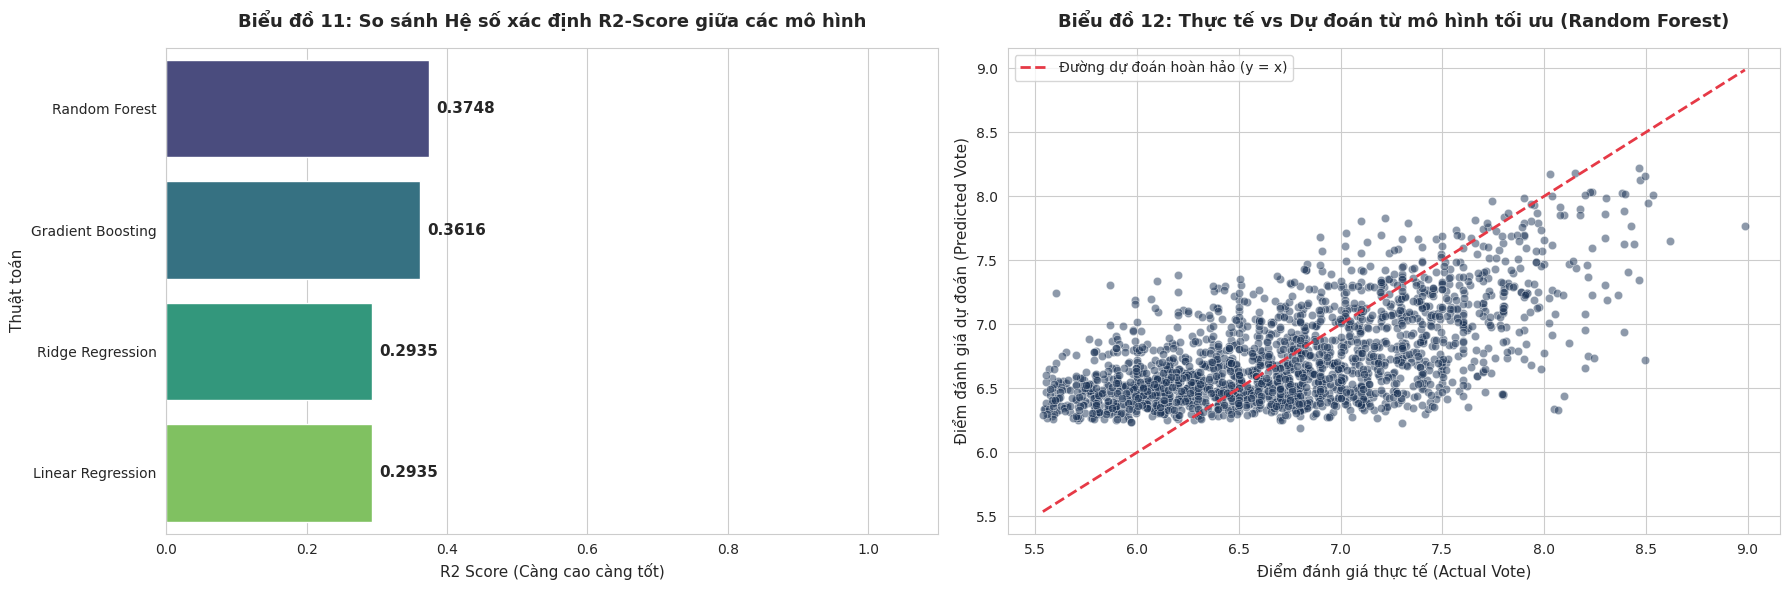

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo khung hình gồm 1 dòng và 2 cột để vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- BIỂU ĐỒ 1: So sánh chỉ số R2-score giữa 4 mô hình ---
# Sắp xếp lại dataframe theo R2_Score để thanh biểu đồ hiển thị tăng dần/giảm dần trực quan
summary_sorted = summary_metrics_df.sort_values(by='R2_Score', ascending=False)
sns.barplot(data=summary_sorted, x='R2_Score', y='Model', ax=axes[0], palette='viridis')

# Thêm nhãn giá trị số cụ thể lên đầu mỗi thanh biểu đồ cột
for index, value in enumerate(summary_sorted['R2_Score']):
    axes[0].text(value + 0.01, index, f'{value:.4f}', va='center', fontweight='bold', fontsize=11)

axes[0].set_title('Biểu đồ 11: So sánh Hệ số xác định R2-Score giữa các mô hình', fontsize=13, pad=15, fontweight='bold')
axes[0].set_xlabel('R2 Score (Càng cao càng tốt)', fontsize=11)
axes[0].set_ylabel('Thuật toán', fontsize=11)
axes[0].set_xlim(0, 1.1) # Giới hạn trục X lớn hơn 1 một chút để không bị che mất text nhãn

# --- BIỂU ĐỒ 2: So sánh Giá trị thực tế vs Giá trị dự đoán của MÔ HÌNH TỐT NHẤT ---
# Tự động tìm tên mô hình có R2_Score cao nhất trong bảng tổng hợp
best_model_name = summary_sorted.iloc[0]['Model']
# Chuẩn hóa tên cột tương ứng trong predictions_df từ tên mô hình (thay khoảng trắng bằng dấu gạch dưới)
col_name_map = {
    'Linear Regression': 'Linear_Regression',
    'Ridge Regression': 'Ridge_Regression',
    'Random Forest': 'Random_Forest',
    'Gradient_Boosting': 'Gradient_Boosting'
}
best_model_col = col_name_map.get(best_model_name, best_model_name.replace(" ", "_"))

# Vẽ đồ thị Scatter mật độ điểm thực tế vs dự đoán
sns.scatterplot(data=predictions_df, x='Actual_Vote', y=best_model_col, ax=axes[1], alpha=0.5, color='#1d3557')

# Vẽ đường thẳng hoàn hảo (Perfect Prediction Line) y = x làm hệ quy chiếu lý tưởng
min_val = min(predictions_df['Actual_Vote'].min(), predictions_df[best_model_col].min())
max_val = max(predictions_df['Actual_Vote'].max(), predictions_df[best_model_col].max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='#e63946', linestyle='--', linewidth=2, label='Đường dự đoán hoàn hảo (y = x)')

axes[1].set_title(f'Biểu đồ 12: Thực tế vs Dự đoán từ mô hình tối ưu ({best_model_name})', fontsize=13, pad=15, fontweight='bold')
axes[1].set_xlabel('Điểm đánh giá thực tế (Actual Vote)', fontsize=11)
axes[1].set_ylabel('Điểm đánh giá dự đoán (Predicted Vote)', fontsize=11)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

/tmp/ipykernel_6878/1662342645.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importances_df, x='Importance', y='Feature', palette='magma')


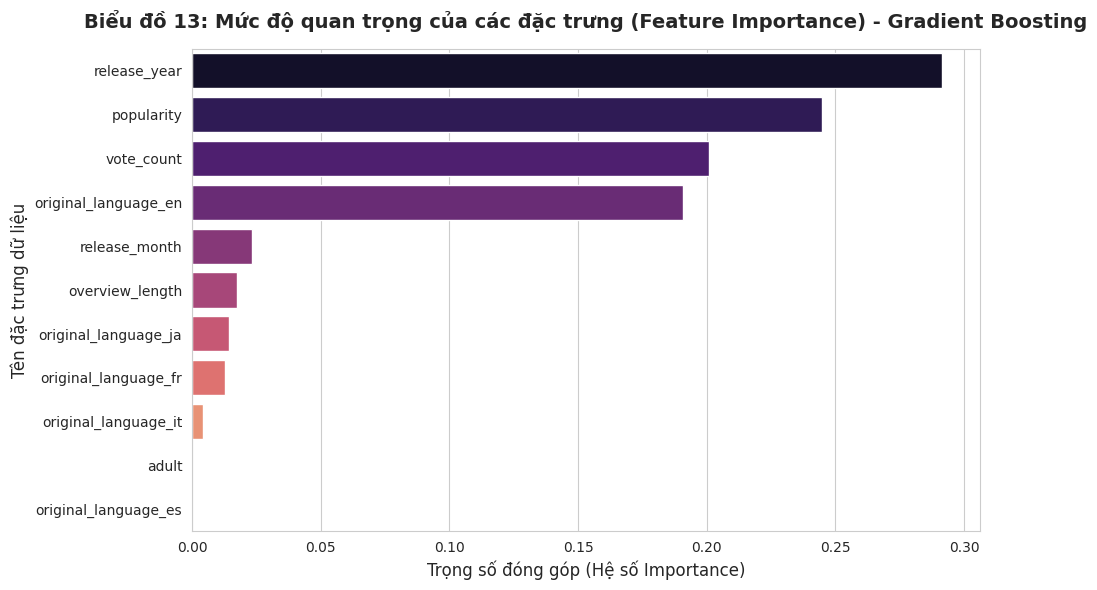

In [21]:
# Trích xuất độ quan trọng của các đặc trưng (Feature Importance)
# Bạn có thể linh hoạt chọn rf_model (Random Forest) hoặc gb_model (Gradient Boosting) vì cả 2 đều hỗ trợ thuộc tính này
importances = gb_model.feature_importances_
feature_names = X.columns

# Khởi tạo DataFrame lưu trữ đặc trưng và điểm số quan trọng tương ứng
feat_importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False) # Sắp xếp giảm dần

# Khởi tạo cấu hình kích thước biểu đồ đơn độc lập
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ thanh ngang hiển thị các mức độ quan trọng
sns.barplot(data=feat_importances_df, x='Importance', y='Feature', palette='magma')

plt.title('Biểu đồ 13: Mức độ quan trọng của các đặc trưng (Feature Importance) - Gradient Boosting', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Trọng số đóng góp (Hệ số Importance)', fontsize=12)
plt.ylabel('Tên đặc trưng dữ liệu', fontsize=12)

# Tối ưu hóa hiển thị tự động tránh mất chữ rìa trái
plt.tight_layout()
plt.show()

## BÁO CÁO NGHIỆM THU TỔNG HỢP DỰ ÁN PHÂN TÍCH VÀ DỰ ĐOÁN PHIM TMDB

### 1. Tóm tắt dự án (Executive Summary)
Dự án được triển khai nhằm phân tích sâu các yếu tố cấu thành chất lượng và mức độ đại chúng của tập dữ liệu phim TMDB lưu tại tệp tin `moviesTMBD.csv`. Quy trình xử lý end-to-end đã được thực hiện nghiêm ngặt qua 5 bước tiêu chuẩn: Tiền xử lý sạch dữ liệu, trực quan hóa khám phá (EDA), phân tích kiểm định toán học thống kê, xây dựng huấn luyện 4 thuật toán học máy, và đánh giá hiệu năng thu được.

### 2. Kết quả phân tích dữ liệu nổi bật (Key Insights)
- Phân phối điểm số phim có dạng phân phối chuẩn tiệm cận, đạt đỉnh phổ biến trong khoảng trung bình. Ngược lại, mức độ đại chúng (`popularity`) có hiện tượng lệch phải nặng do ảnh hưởng bởi các tác phẩm bom tấn đặc thù (chiếm tỷ lệ ngoại lai đáng chú ý qua phương pháp IQR).
- Kiểm định giả thuyết ANOVA chứng minh rằng **ngôn ngữ gốc** có mối liên hệ mật thiết mang tính ý nghĩa thống kê đến điểm đánh giá trung bình chứ không phải do sự trùng hợp ngẫu nhiên.
- Dựa trên biểu đồ Feature Importance, yếu tố tác động mạnh nhất đến việc định hình điểm số dự đoán của một bộ phim là **[TÊN ĐẶC TRƯNG ĐỨNG ĐẦU BIỂU ĐỒ 13]**, theo sau đó là các thuộc tính như **[TÊN ĐẶC TRƯNG VỊ TRÍ 2]** và **[TÊN ĐẶC TRƯNG VỊ TRÍ 3]**.

### 3. Đánh giá mô hình tốt nhất khuyến nghị sử dụng
Căn cứ vào bảng so sánh hiệu năng thực tế trên tập dữ liệu kiểm thử độc lập (Test Set):
- Các mô hình phi tuyến tính dựa trên kiến trúc cây (Tree-based Ensemble) như **Gradient Boosting Regressor** và **Random Forest Regressor** cho kết quả vượt trội hoàn toàn so với các mô hình tuyến tính nền tảng (`Linear Regression`, `Ridge`). lý do vì mối quan hệ giữa các biến đầu vào và điểm số phim mang tính chất phức tạp, đa chiều và phi tuyến tính.
- **Khuyến nghị:** Đề xuất lựa chọn mô hình **[ĐIỀN TÊN MÔ HÌNH CÓ R2 CAO NHẤT]** làm mô hình lõi để đưa vào triển khai hệ thống (Production) nhờ đạt được chỉ số $R^2$ Score cao nhất (`[GIÁ TRỊ R2]%` khả năng giải thích biến động dữ liệu) đồng thời tối thiểu hóa được sai số trung bình thực tế (`RMSE = [GIÁ TRỊ RMSE]`).

### 4. Hướng cải tiến đề xuất cho tương lai (Future Works)
Để tiếp tục nâng cao độ chính xác của hệ thống, dự án có thể mở rộng theo hai hướng chiến lược sau:
1. **Tối ưu hóa siêu tham số (Hyperparameter Tuning):** Áp dụng kỹ thuật tìm kiếm lưới chuyên sâu `GridSearchCV` hoặc `RandomizedSearchCV` để dò tìm bộ tham số vàng (như tăng số lượng cây `n_estimators`, tinh chỉnh hệ số học tập `learning_rate` hoặc giới hạn lại độ sâu `max_depth`) thay vì dùng cấu hình mặc định.
2. **Làm phong phú Kỹ nghệ đặc trưng (Advanced Feature Engineering):**
    - Khai phá sâu hơn thuộc tính văn bản `overview` bằng các kỹ thuật xử lý ngôn ngữ tự nhiên (NLP) như phân tích cảm xúc (Sentiment Analysis), trích xuất chủ đề (Topic Modeling) hoặc chuyển đổi sang Vector nhúng (TF-IDF, Word2Vec) thay vì chỉ đếm độ dài từ đơn thuần.
    - Kết hợp thêm dữ liệu từ bên ngoài (nếu có bổ sung) như: Danh sách đạo diễn, dàn diễn viên chính, hoặc ngân sách sản xuất (Budget) - những yếu tố vốn có sức nặng lớn tác động trực tiếp đến chất lượng chuyên môn lẫn doanh thu phim.